In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json
import os
import glob

In [2]:
#female_adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/female_jan_26_dense.h5ad')
#male_adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/male_jan_26_dense.h5ad')
adata_whole = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad')

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
# join sex and condition and create a new column in obs
# convert sex and condition to string
adata_whole.obs['sex'] = adata_whole.obs['sex'].astype(str)
adata_whole.obs['condition'] = adata_whole.obs['condition'].astype(str)
adata_whole.obs['sex_condition'] = adata_whole.obs['sex'] + '_' + adata_whole.obs['condition']

In [4]:
adata_whole.obs

,sample_id,cell_type,condition,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,total_counts_hb_cb,log1p_total_counts_hb_cb,pct_counts_hb_cb,n_genes,sex,batch,_scvi_batch,_scvi_labels,C_scANVI,sex_condition
AAACCCAAGATTCGAA-1,F7_KO,Fast IIX,KO,0.031034,0.999955,4220.201172,1.249208,1798,7.494986,4214,...,0,0.0,0.0,1798,F,2024,0,3,Fast IIX,F_KO
AAACCCACACTCATAG-1,F7_KO,Fast IIB,KO,0.038591,0.998573,3995.092041,1.000975,1400,7.244942,3139,...,0,0.0,0.0,1400,F,2024,0,2,Fast IIB,F_KO
AAACCCACAGCCTTCT-1,F7_KO,Fast IIX,KO,0.020231,0.999955,5067.773438,1.299482,2042,7.622175,5519,...,0,0.0,0.0,2042,F,2024,0,3,Fast IIX,F_KO
AAACCCACAGTATGAA-1,F7_KO,Fast IIX,KO,0.025974,0.999955,4462.444336,1.488916,2029,7.615791,5397,...,0,0.0,0.0,2029,F,2024,0,3,Fast IIX,F_KO
AAACCCACATCATTGG-1,F7_KO,Fast IIX,KO,0.119454,0.999957,3054.103760,0.886010,998,6.906755,1806,...,0,0.0,0.0,998,F,2024,0,3,Fast IIX,F_KO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGCCCTCATATCCC-1,M6_WT,Unknown,WT,0.260239,0.999354,2003.506958,0.802182,535,6.284134,867,...,0,0.0,0.0,535,M,2025,1,10,Fast IIX,M_WT
TGTGCCCTCCACCTGC-1,M6_WT,Unknown,WT,0.228600,0.999950,2426.421387,1.073309,751,6.622736,1559,...,0,0.0,0.0,751,M,2025,1,10,Pericyte,M_WT
TGTGCCCTCCTCTCTC-1,M6_WT,Unknown,WT,0.148233,0.999252,2246.069580,1.030120,897,6.800170,1494,...,0,0.0,0.0,897,M,2025,1,10,EC,M_WT
TGTGCCCTCGTCTCGC-1,M6_WT,Unknown,WT,0.108752,0.999906,2318.659424,1.087894,906,6.810142,1721,...,0,0.0,0.0,906,M,2025,1,10,Fast IIB,M_WT


### Cell proportions
#### 1. Sankey plot for 4 subsets where the width of the flow shows how much of that category's population maps to the different cell types
#### 2. Pie charts to show cell-type population differences between male and female

In [8]:
#df = adata_whole.obs.groupby(['sex_condition', 'C_scANVI']).size().reset_index(name='count')
df = adata_whole.obs.groupby(['sex', 'C_scANVI']).size().reset_index(name='count')

# rename sex_condition to group
# df = df.rename(columns={'sex_condition': 'group'})
df = df.rename(columns={'sex': 'group'})
# rename C_scANVI to cell_type
df = df.rename(columns={'C_scANVI': 'cell_type'})
display(df.head())

,group,cell_type,count
0,F,EC,1468
1,F,FAPs,1119
2,F,Fast IIB,14929
3,F,Fast IIX,18827
4,F,MTJ,2618


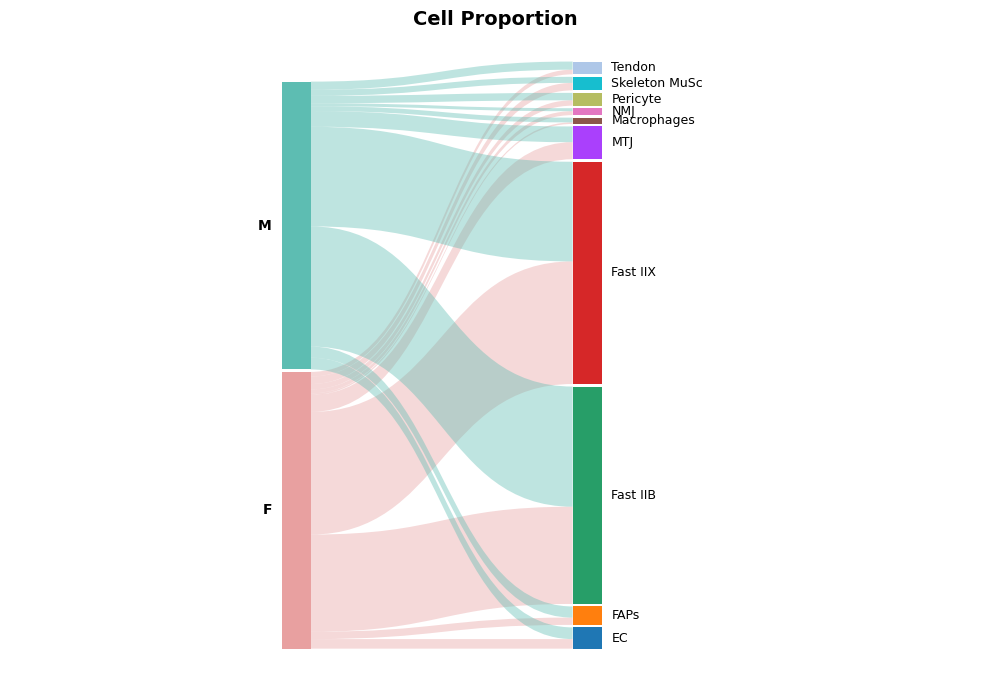

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patches as patches
import pandas as pd

# ── CONFIG ──────────────────────────────────────────────────────────────────
LEFT_COL   = 'sex'
RIGHT_COL  = 'C_scANVI'
LEFT_ORDER = ['F', 'M']

COLOR_MAP = {
    'F': '#e8a0a0',
    'M': '#5dbdb2',
}

# scanpy cell type colors — auto-pulled or define manually
cell_type_colors = dict(zip(
    adata_whole.obs[RIGHT_COL].cat.categories,
    adata_whole.uns.get(f'{RIGHT_COL}_colors', 
        plt.cm.tab20.colors[:len(adata_whole.obs[RIGHT_COL].cat.categories)])
))

# ── DATA ────────────────────────────────────────────────────────────────────
df = adata_whole.obs.groupby([LEFT_COL, RIGHT_COL]).size().reset_index(name='count')

left_groups  = LEFT_ORDER
right_groups = adata_whole.obs[RIGHT_COL].cat.categories.tolist()

# Normalize counts within each left group (proportions)
totals = df.groupby(LEFT_COL)['count'].transform('sum')
df['prop'] = df['count'] / totals

# ── LAYOUT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

BAR_W  = 0.03
GAP    = 0.008
X_LEFT = 0.28   # wider left margin for labels
X_RIGHT= 0.58   # closer to left bar
ALPHA  = 0.4

def calc_positions(groups, counts_dict, x_pos, bar_w):
    """Return {group: (y_bottom, y_top)} for stacked bars."""
    total = sum(counts_dict[g] for g in groups)
    positions = {}
    y = 0.05
    for g in groups:
        h = (counts_dict[g] / total) * 0.9
        positions[g] = (y, y + h)
        y += h + GAP * 0.5
    return positions

# Totals for sizing
left_totals  = df.groupby(LEFT_COL)['count'].sum().to_dict()
right_totals = df.groupby(RIGHT_COL)['count'].sum().to_dict()

left_pos  = calc_positions(left_groups,  left_totals,  X_LEFT,  BAR_W)
right_pos = calc_positions(right_groups, right_totals, X_RIGHT, BAR_W)

# ── DRAW FLOWS ──────────────────────────────────────────────────────────────
# Track current fill position for each bar
left_fill  = {g: left_pos[g][0]  for g in left_groups}
right_fill = {g: right_pos[g][0] for g in right_groups}

left_total_sum = sum(left_totals.values())

for _, row in df.sort_values([LEFT_COL, RIGHT_COL]).iterrows():
    lg, rg, cnt = row[LEFT_COL], row[RIGHT_COL], row['count']

    l_total = left_totals[lg]
    r_total = right_totals[rg]
    l_span  = (left_pos[lg][1] - left_pos[lg][0])
    r_span  = (right_pos[rg][1] - right_pos[rg][0])

    lh = (cnt / l_total) * l_span
    rh = (cnt / r_total) * r_span

    ly0 = left_fill[lg]
    ry0 = right_fill[rg]
    ly1 = ly0 + lh
    ry1 = ry0 + rh

    left_fill[lg]  += lh
    right_fill[rg] += rh

    # Bezier curve path
    verts = [
        (X_LEFT + BAR_W, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly0),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry0),
        (X_RIGHT, ry0),
        (X_RIGHT, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ry1),
        ((X_LEFT + BAR_W + X_RIGHT) / 2, ly1),
        (X_LEFT + BAR_W, ly1),
        (X_LEFT + BAR_W, ly0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    path  = Path(verts, codes)
    patch = patches.PathPatch(
        path,
        facecolor=COLOR_MAP[lg],
        edgecolor='none',
        alpha=ALPHA,
        zorder=1
    )
    ax.add_patch(patch)

# ── DRAW BARS ────────────────────────────────────────────────────────────────
for g in left_groups:
    y0, y1 = left_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_LEFT, y0), BAR_W, y1 - y0,
        color=COLOR_MAP[g], zorder=2, linewidth=0
    ))
    ax.text(X_LEFT - 0.01, (y0 + y1) / 2, g,
            ha='right', va='center', fontsize=10, fontweight='bold')

for g in right_groups:
    y0, y1 = right_pos[g]
    ax.add_patch(plt.Rectangle(
        (X_RIGHT, y0), BAR_W, y1 - y0,
        color=cell_type_colors.get(g, '#aaaaaa'), zorder=2, linewidth=0
    ))
    ax.text(X_RIGHT + BAR_W + 0.01, (y0 + y1) / 2, g,
            ha='left', va='center', fontsize=9)

plt.title('Cell Proportion', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/figures/sankey_M_F_to_cell_type.pdf', bbox_inches='tight', dpi=300)
# plt.savefig('sankey_moscot_style.png', bbox_inches='tight', dpi=300)
plt.show()

In [20]:
# Set the figures directory first
sc.settings.figdir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/figures'

# Then save= is just the filename suffix
sc.pl.umap(adata_whole, color=['C_scANVI'], show=False, save='_C_scANVI.pdf')

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'C_scANVI'}, xlabel='UMAP1', ylabel='UMAP2'>